In [1]:
## Importing Libraries

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [2]:
## Setting Directories

ROOT_DIR = Path.cwd().parent

DATASET_DIR = ROOT_DIR / "datasets" / "processed_dataset"
FEATURE_DIR = DATASET_DIR / "ml_features"
MODELS_DIR = ROOT_DIR / "models"

print("Feature Directory:")
print(FEATURE_DIR)

Feature Directory:
c:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\processed_dataset\ml_features


In [3]:
## Loading Features Datasets

train_df = pd.read_csv(FEATURE_DIR / "train_features.csv")
val_df = pd.read_csv(FEATURE_DIR / "val_features.csv")
test_df = pd.read_csv(FEATURE_DIR / "test_features.csv")

print("=" * 50)

print("Train :", train_df.shape)
print("Val   :", val_df.shape)
print("Test  :", test_df.shape)

Train : (3948, 1102)
Val   : (846, 1102)
Test  : (847, 1102)


In [4]:
## Features & Labels

X_train = train_df.drop(columns=["Label"])
y_train = train_df["Label"]

X_val = val_df.drop(columns=["Label"])
y_val = val_df["Label"]

X_test = test_df.drop(columns=["Label"])
y_test = test_df["Label"]

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

Training Features : (3948, 1101)
Testing Features  : (847, 1101)


In [5]:
## Model Evaluation Function

results = []

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results.append({"Model": model_name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1})

    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(classification_report(y_true, y_pred, zero_division=0))
    return accuracy, precision, recall, f1

print("Evaluation Pipeline Ready.")

Evaluation Pipeline Ready.


In [6]:
## Training Logistic Regression Model

log_reg = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train, y_train)

print("Logistic Regression Training Completed.")

c:\Users\Akshat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression Training Completed.


Logistic Regression
              precision    recall  f1-score   support

           0       0.43      0.44      0.44        52
           1       0.31      0.48      0.38        44
           2       0.21      0.20      0.20        75
           3       0.51      0.47      0.49        88
           4       0.38      0.34      0.36       182
           5       0.33      0.38      0.35        68
           6       0.42      0.40      0.41       167
           7       0.19      0.25      0.21        20
           8       0.33      0.28      0.30        57
           9       0.30      0.31      0.31        29
          10       0.00      0.00      0.00        14
          11       0.11      0.12      0.11        51

    accuracy                           0.34       847
   macro avg       0.29      0.31      0.30       847
weighted avg       0.35      0.34      0.34       847



<Figure size 800x600 with 0 Axes>

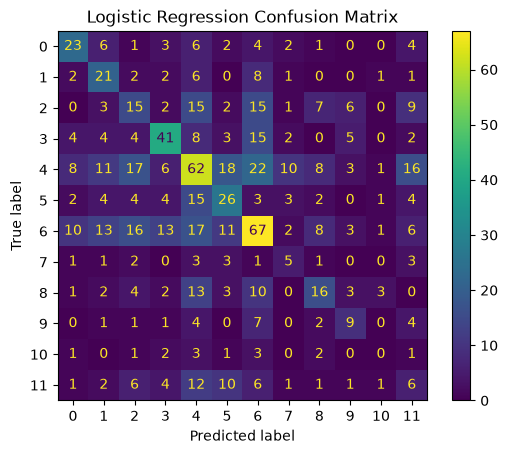

In [7]:
## Evaluating Logistic Regression Model

log_pred = log_reg.predict(X_test)

evaluate_model("Logistic Regression", y_test, log_pred)
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [8]:
## Training Decision Tree Model

decision_tree = DecisionTreeClassifier(max_depth=20, random_state=42)
decision_tree.fit(X_train, y_train)

print("Decision Tree Training Completed.")

Decision Tree Training Completed.


Decision Tree
              precision    recall  f1-score   support

           0       0.48      0.46      0.47        52
           1       0.30      0.34      0.32        44
           2       0.20      0.21      0.21        75
           3       0.40      0.41      0.40        88
           4       0.39      0.41      0.40       182
           5       0.41      0.38      0.40        68
           6       0.38      0.34      0.36       167
           7       0.23      0.15      0.18        20
           8       0.19      0.21      0.20        57
           9       0.28      0.24      0.26        29
          10       0.00      0.00      0.00        14
          11       0.20      0.20      0.20        51

    accuracy                           0.33       847
   macro avg       0.29      0.28      0.28       847
weighted avg       0.33      0.33      0.33       847



<Figure size 800x600 with 0 Axes>

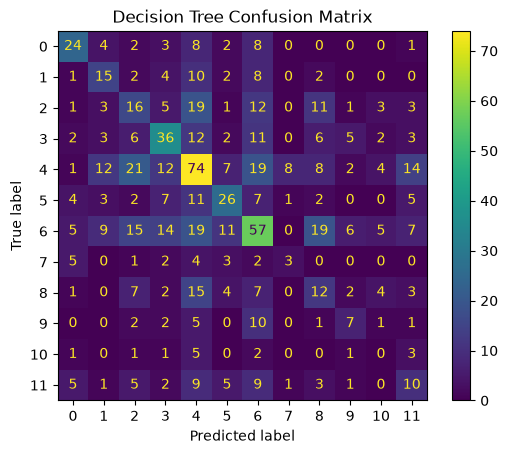

In [9]:
## Evaluating Decision Tree Model

dt_pred = decision_tree.predict(X_test)
evaluate_model("Decision Tree", y_test, dt_pred)
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [10]:
## Training Random Forest Model


random_forest = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)

print("Random Forest Training Completed.")

Random Forest Training Completed.


Random Forest
              precision    recall  f1-score   support

           0       0.66      0.48      0.56        52
           1       1.00      0.07      0.13        44
           2       0.67      0.03      0.05        75
           3       0.77      0.50      0.61        88
           4       0.35      0.82      0.49       182
           5       0.82      0.46      0.58        68
           6       0.41      0.63      0.50       167
           7       1.00      0.05      0.10        20
           8       0.39      0.12      0.19        57
           9       1.00      0.17      0.29        29
          10       0.00      0.00      0.00        14
          11       0.75      0.06      0.11        51

    accuracy                           0.44       847
   macro avg       0.65      0.28      0.30       847
weighted avg       0.58      0.44      0.39       847



<Figure size 800x600 with 0 Axes>

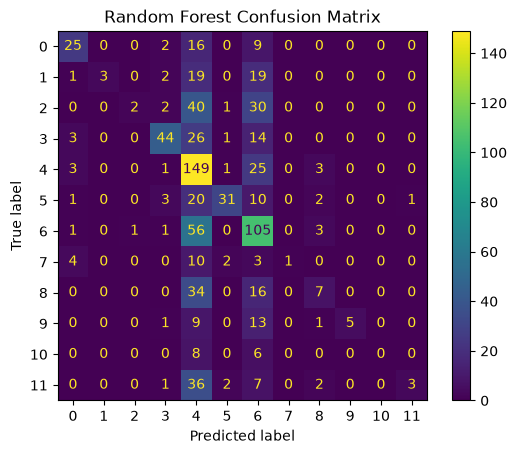

In [11]:
## Evaluating Random Forest Model

rf_pred = random_forest.predict(X_test)
evaluate_model("Random Forest", y_test, rf_pred)
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [12]:
print("Train:", sorted(np.unique(y_train)))
print("Val  :", sorted(np.unique(y_val)))
print("Test :", sorted(np.unique(y_test)))

Train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Val  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Test : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


In [13]:
## Training XGBoost Model

num_classes = len(np.unique(y_train))
xgb_model = XGBClassifier(objective="multi:softmax", num_class=num_classes, n_estimators=300, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print("XGBoost Training Completed.")

XGBoost Training Completed.


XGBoost
              precision    recall  f1-score   support

           0       0.65      0.58      0.61        52
           1       0.70      0.36      0.48        44
           2       0.48      0.35      0.40        75
           3       0.73      0.53      0.62        88
           4       0.46      0.73      0.56       182
           5       0.73      0.63      0.68        68
           6       0.52      0.73      0.61       167
           7       1.00      0.30      0.46        20
           8       0.63      0.30      0.40        57
           9       0.71      0.59      0.64        29
          10       0.00      0.00      0.00        14
          11       0.61      0.22      0.32        51

    accuracy                           0.55       847
   macro avg       0.60      0.44      0.48       847
weighted avg       0.58      0.55      0.54       847



<Figure size 800x600 with 0 Axes>

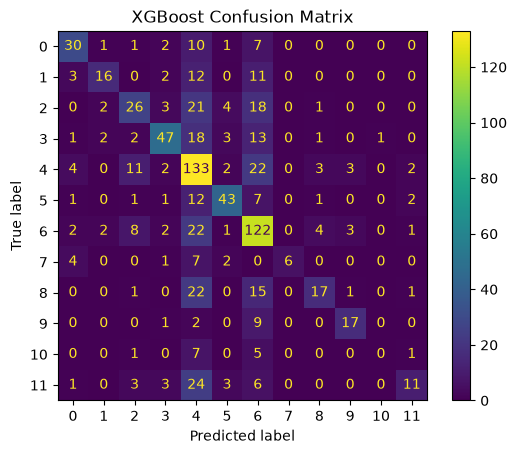

In [14]:
## Evaluating XGBoost Model

xgb_pred = xgb_model.predict(X_test)
evaluate_model("XGBoost", y_test, xgb_pred)
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

In [15]:
## Model Comparison

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

display(results_df)

print("\nBest Model:")
print(results_df.iloc[0]["Model"])

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.552538,0.581560,0.552538,0.536777
2,Random Forest,0.442739,0.582490,0.442739,0.390235
0,Logistic Regression,0.343566,0.347361,0.343566,0.343725
1,Decision Tree,0.330579,0.334338,0.330579,0.331806



Best Model:
XGBoost


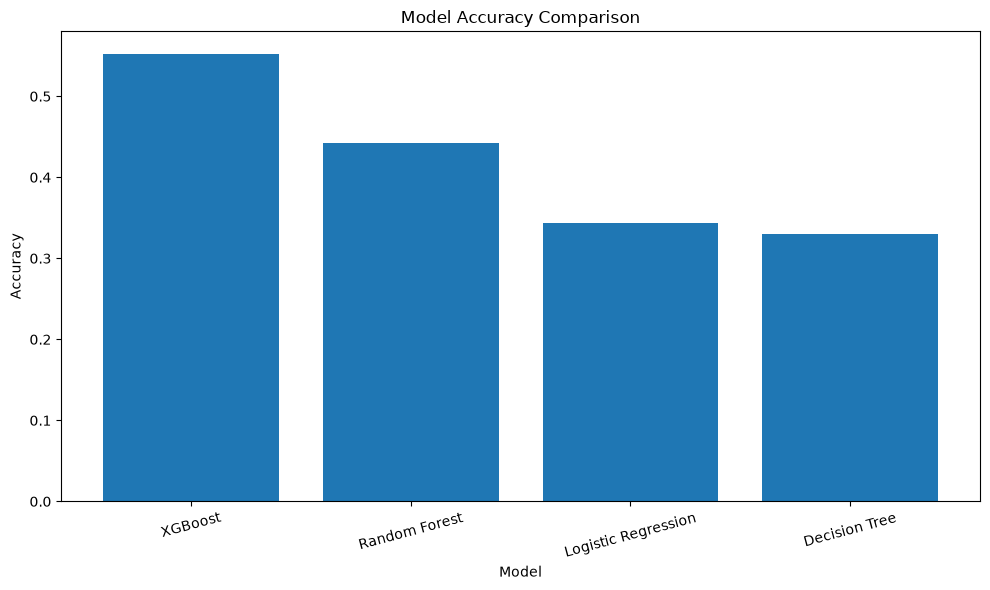

In [16]:
## Accuracy Comparison

plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["Accuracy"])

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [17]:
## Saving Models

joblib.dump(log_reg, MODELS_DIR / "logistic_regression.pkl")
joblib.dump(decision_tree, MODELS_DIR / "decision_tree.pkl")
joblib.dump(random_forest, MODELS_DIR / "random_forest.pkl")
joblib.dump(xgb_model, MODELS_DIR / "xgboost.pkl")

results_df.to_csv(FEATURE_DIR / "model_comparison.csv", index=False)

print("All Models Saved Successfully.")

All Models Saved Successfully.
